In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(style="whitegrid")

In [3]:
df = pd.read_csv("data/marketing_clean.csv")
print("Shape:", df.shape)

Shape: (56000, 37)


In [4]:
df['Seg_High_Income']       = (df['Income'] > 75000).astype(int)
df['Seg_Young_Customer']    = (df['Age'] < 30).astype(int)
df['Seg_Campaign_Responder']= (df['Response'] == 1).astype(int)
df['Seg_High_Web']          = (df['NumWebVisitsMonth'] > 5).astype(int)
df['Seg_Family']            = (df['Children'] > 0).astype(int)
df['Seg_High_Spender']      = (df['Total_Spend'] > df['Total_Spend'].quantile(0.90)).astype(int)

df[['Seg_High_Income','Seg_Young_Customer','Seg_Campaign_Responder',
    'Seg_High_Web','Seg_Family','Seg_High_Spender']].head()

,Seg_High_Income,Seg_Young_Customer,Seg_Campaign_Responder,Seg_High_Web,Seg_Family,Seg_High_Spender
0,0,0,0,0,1,0
1,0,0,0,0,1,0
2,1,0,0,0,0,0
3,0,0,0,0,1,0
4,0,0,0,1,1,0


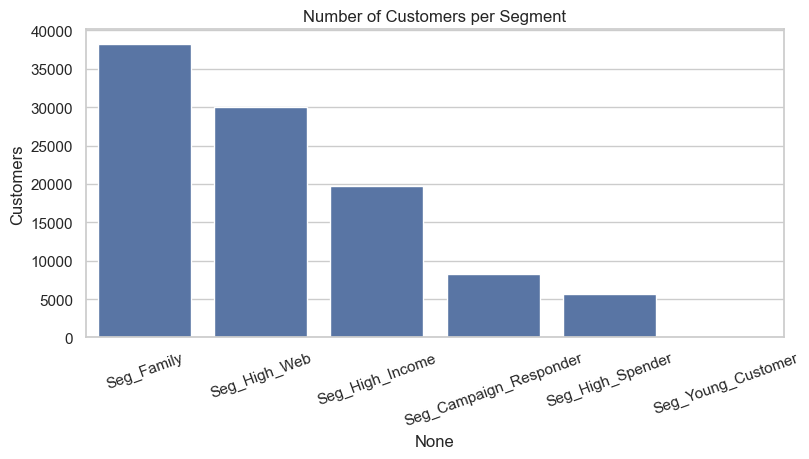

Seg_Family                38222
Seg_High_Web              29970
Seg_High_Income           19782
Seg_Campaign_Responder     8265
Seg_High_Spender           5599
Seg_Young_Customer            0
dtype: int64


In [5]:
seg_cols = ['Seg_High_Income','Seg_Young_Customer','Seg_Campaign_Responder',
            'Seg_High_Web','Seg_Family','Seg_High_Spender']

seg_sizes = df[seg_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 4))
sns.barplot(x=seg_sizes.index, y=seg_sizes.values)
plt.title("Number of Customers per Segment")
plt.ylabel("Customers")
plt.xticks(rotation=20)
plt.show()

print(seg_sizes)

In [6]:
kpi = []
for seg in seg_cols:
    members = df[df[seg] == 1]
    kpi.append({
        'Segment': seg,
        'Customers': len(members),
        'Response %': round(members['Response'].mean() * 100, 1),
        'Avg Spend': round(members['Total_Spend'].mean(), 0),
        'Avg Income': round(members['Income'].mean(), 0)
    })

kpi_df = pd.DataFrame(kpi)
kpi_df

,Segment,Customers,Response %,Avg Spend,Avg Income
0,Seg_High_Income,19782,23.5,1038.0,94998.0
1,Seg_Young_Customer,0,NaN,NaN,NaN
2,Seg_Campaign_Responder,8265,100.0,939.0,75317.0
3,Seg_High_Web,29970,12.1,510.0,48627.0
4,Seg_Family,38222,11.6,500.0,48494.0
5,Seg_High_Spender,5599,26.0,1972.0,87842.0


###  Takeaway — Segment KPIs
- **High Spender (26%, ₹1,972) & High Income (23.5%, ₹1,038)** are the most valuable segments — small but high-response, high-spend.
- The **largest segments (Family, High Web)** have the **lowest** response & spend → size ≠ value.
- Young Customer is empty; Campaign Responder's 100% is definitional.
- **Action:** prioritise **High Spender + High Income** for premium campaigns.

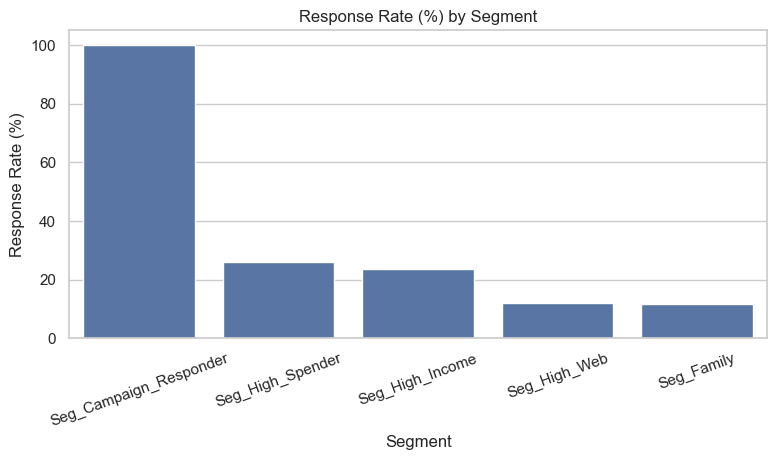

In [7]:
plot_df = kpi_df.dropna().sort_values('Response %', ascending=False)

plt.figure(figsize=(9, 4))
sns.barplot(x='Segment', y='Response %', data=plot_df)
plt.title("Response Rate (%) by Segment")
plt.ylabel("Response Rate (%)")
plt.xticks(rotation=20)
plt.show()

In [8]:
df.to_csv("data/marketing_segmented.csv", index=False)
print("Saved with segment flags! Shape:", df.shape)

Saved with segment flags! Shape: (56000, 43)


##  Segmentation Summary

Six rule-based segments built from business rules:

| Segment | Rule | Size | Response % | Avg Spend |
|---------|------|-----:|-----------:|----------:|
| High Spender | Total_Spend > 90th pct | 5,599 | 26.0% | ₹1,972 |
| High Income | Income > 75k | 19,782 | 23.5% | ₹1,038 |
| Campaign Responder | Response = 1 | 8,265 | 100%* | ₹939 |
| High Web Engagement | Web visits > 5 | 29,970 | 12.1% | ₹510 |
| Family | Children > 0 | 38,222 | 11.6% | ₹500 |
| Young Customer | Age < 30 | 0 | — | — |

*Campaign Responder is 100% by definition.

**Key insight:** Size ≠ value — the *smallest* segments (High Spender, High Income) are the *most valuable*; the largest (Family, High Web) underperform. Young Customer is empty (no under-30s).

**Recommendation:** prioritise **High Spender + High Income** for premium campaigns.